# Course 2 Week 4: Word Embeddings with CBOW

## Natural Language Processing with Probabilistic Models

This notebook provides a complete hands-on implementation of word embeddings using the Continuous Bag-of-Words (CBOW) model, covering all topics from preprocessing to evaluation.

---

## 1. Setup and Imports

Setting up our environment for building word embeddings from scratch.


In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
import re
import string
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")

All libraries imported successfully!
NumPy version: 2.1.3


## 2. Basic Word Representations - Traditional Approaches

Understanding the limitations of traditional word representation methods.

### One-Hot Encoding Example


In [74]:
# Small vocabulary example
vocabulary = ['king', 'queen', 'man', 'woman', 'apple']
vocab_size = len(vocabulary)

# Create word to index mapping
word2idx = {word: idx for idx, word in enumerate(vocabulary)}
idx2word = {idx: word for word, idx in word2idx.items()}

print(f"Vocabulary size: {vocab_size}")
print(f"\nWord to Index mapping:\n{word2idx}")

print(f"\nIndex to Word mapping:\n{idx2word}")

# One-hot encoding function
def one_hot_encode(word, word2idx, vocab_size):
    """Convert word to one-hot vector"""
    vector = np.zeros(vocab_size)
    if word in word2idx:
        # word2idx = {'king': 0, 'queen': 1, 'man': 2, 'woman': 3, 'apple': 4}
        # word2idx[word] will give the index and we will put the value as 1 only for that index
        vector[word2idx[word]] = 1
    return vector

# Demonstrate one-hot encoding
word = 'king'
one_hot = one_hot_encode(word, word2idx, vocab_size)
print(f"\nOne-hot encoding of '{word}':")
print(one_hot)
print(f"Shape: {one_hot.shape}")
print(f"Sparsity: {(one_hot == 0).sum()}/{len(one_hot)} elements are zero")

Vocabulary size: 5

Word to Index mapping:
{'king': 0, 'queen': 1, 'man': 2, 'woman': 3, 'apple': 4}

Index to Word mapping:
{0: 'king', 1: 'queen', 2: 'man', 3: 'woman', 4: 'apple'}

One-hot encoding of 'king':
[1. 0. 0. 0. 0.]
Shape: (5,)
Sparsity: 4/5 elements are zero


### Limitations of One-Hot Encoding


In [42]:
# Compute similarity between one-hot vectors
king_vec = one_hot_encode('king', word2idx, vocab_size)
queen_vec = one_hot_encode('queen', word2idx, vocab_size)
apple_vec = one_hot_encode('apple', word2idx, vocab_size)

# Dot product (similarity measure)
king_queen_sim = np.dot(king_vec, queen_vec)
king_apple_sim = np.dot(king_vec, apple_vec)

print("One-hot Vector Similarities (Dot Product):")
print(f"king · queen = {king_queen_sim}")
print(f"king · apple = {king_apple_sim}")
print("\nProblem: All words are equally dissimilar (orthogonal vectors)")
print("No semantic relationship captured!")

One-hot Vector Similarities (Dot Product):
king · queen = 0.0
king · apple = 0.0

Problem: All words are equally dissimilar (orthogonal vectors)
No semantic relationship captured!


## 3. Sample Text Corpus

Creating a larger corpus for training word embeddings.

In [43]:
def preprocess_text(text):
    """
    Comprehensive text preprocessing
    Steps: lowercase → remove punctuation → tokenize
    """
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize (split into words)
    tokens = text.split()

    return tokens

In [44]:
# Enhanced corpus - comprehensive coverage for all evaluation tasks
corpus = [
    # Original NLP and ML content
    "I love natural language processing",
    "Natural language processing is fascinating",
    "Machine learning and deep learning are exciting",
    "Deep learning models learn from data",
    "I enjoy learning about neural networks",
    "Neural networks process information efficiently",
    "Language models understand text context",
    "Context is important for understanding language",
    "Word embeddings capture semantic meaning",
    "Semantic relationships exist between words",
    
    # Royal/Gender relations (for analogies)
    "The king rules his kingdom wisely",
    "The queen is the king's wife",
    "The king and queen live in the palace",
    "A king has great power and responsibility",
    "The queen supports the king in ruling",
    "Every kingdom needs a wise king",
    "The beautiful queen wears a crown",
    "Kings and queens are royal figures",
    
    # Man/Woman relations (for analogies)
    "A man and a woman are people",
    "The boy grew up to be a man",
    "The girl grew up to be a woman",
    "Every man and woman deserves respect",
    "A man works hard for his family",
    "A woman can achieve anything",
    "The man and woman walked together",
    "Both man and woman contribute to society",
    
    # Geography and capitals
    "Paris is the capital of France",
    "London is the capital of England",
    "The beautiful city of Paris attracts tourists",
    "London is a historic city",
    
    # Technical content
    "Machine translation requires understanding",
    "Understanding context improves translation quality",
    "Text classification uses word vectors",
    "Word vectors represent semantic information",
    
    # Sentiment-related vocabulary (CRITICAL for sentiment task)
    "I love this amazing product very much",
    "Great quality service makes me happy",
    "Excellent results satisfy my needs",
    "Happy customers love great service",
    "I am very satisfied with quality",
    "Amazing products bring happiness",
    "Terrible experiences make people unhappy",
    "Poor quality leads to bad reviews",
    "Not satisfied means bad experience",
    "Bad service creates terrible problems",
    "Waste of money is a poor choice",
    
    # Additional sentiment vocabulary
    "Love and happiness are positive emotions",
    "Great and excellent describe quality",
    "Terrible and poor indicate problems",
    "Satisfied customers are happy customers",
    "Bad experiences lead to complaints",
    "Quality products make people happy",
    "Service quality affects satisfaction",
    "Amazing results exceed expectations",
    
    # More context for better embeddings
    "Learning from experience improves understanding",
    "Quality and excellence require effort",
    "Happy people love positive experiences",
    "Negative experiences create bad memories",
    "Good service leads to satisfaction",
    "Poor choices waste resources",
    "Great decisions bring rewards",
    "Terrible mistakes cause problems",
    
    # Additional semantic relationships
    "Understanding language requires context",
    "Processing information takes time",
    "Neural networks learn patterns",
    "Deep models capture complexity",
    "Word meaning depends on context",
    "Semantic similarity helps understanding",
    "Vector representations encode meaning",
    "Embedding spaces capture relationships",
]

print(f"Enhanced Corpus Statistics:")
print(f"=" * 60)
print(f"Number of sentences: {len(corpus)}")
print(f"Total characters: {sum(len(s) for s in corpus)}")

# Check vocabulary coverage
from collections import Counter
all_words = []
for sentence in corpus:
    all_words.extend(preprocess_text(sentence))

vocab_counts = Counter(all_words)
print(f"Unique words in corpus: {len(vocab_counts)}")
print(f"Total words: {len(all_words)}")

# Check for critical words
critical_words = ['king', 'queen', 'man', 'woman', 'love', 'happy', 
                  'terrible', 'satisfied', 'great', 'poor', 'bad', 
                  'excellent', 'amazing', 'quality', 'service']

print(f"\nCritical Word Coverage:")
for word in critical_words:
    count = vocab_counts.get(word, 0)
    status = "✓" if count > 0 else "✗"
    print(f"  {status} '{word}': {count} occurrences")

print(f"\nTop 20 most frequent words:")
for word, count in vocab_counts.most_common(20):
    print(f"  {word}: {count}")

Enhanced Corpus Statistics:
Number of sentences: 69
Total characters: 2474
Unique words in corpus: 179
Total words: 374

Critical Word Coverage:
  ✓ 'king': 5 occurrences
  ✓ 'queen': 4 occurrences
  ✓ 'man': 6 occurrences
  ✓ 'woman': 6 occurrences
  ✓ 'love': 5 occurrences
  ✓ 'happy': 5 occurrences
  ✓ 'terrible': 4 occurrences
  ✓ 'satisfied': 3 occurrences
  ✓ 'great': 5 occurrences
  ✓ 'poor': 4 occurrences
  ✓ 'bad': 5 occurrences
  ✓ 'excellent': 2 occurrences
  ✓ 'amazing': 3 occurrences
  ✓ 'quality': 8 occurrences
  ✓ 'service': 5 occurrences

Top 20 most frequent words:
  the: 14
  and: 12
  a: 11
  quality: 8
  is: 7
  understanding: 6
  man: 6
  woman: 6
  to: 6
  love: 5
  language: 5
  learning: 5
  are: 5
  context: 5
  king: 5
  great: 5
  service: 5
  happy: 5
  bad: 5
  i: 4


## 4. Text Preprocessing and Tokenization

Cleaning and preparing text data for training.


In [45]:
def preprocess_text(text):
    """
    Comprehensive text preprocessing
    Steps: lowercase → remove punctuation → tokenize
    """
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize (split into words)
    tokens = text.split()

    return tokens

# Process entire corpus
tokenized_corpus = []
all_tokens = []

for sentence in corpus:
    tokens = preprocess_text(sentence)
    tokenized_corpus.append(tokens)
    all_tokens.extend(tokens)

print("Preprocessing Results:")
print(f"Total tokens: {len(all_tokens)}")
print(f"Unique tokens: {len(set(all_tokens))}")

print(f"\nOriginal sentence: {corpus[0]}")
print(f"Tokenized: {tokenized_corpus[0]}")

print("\nTokenized_corpus : ",tokenized_corpus)
print("All_tokens : ",all_tokens)

Preprocessing Results:
Total tokens: 374
Unique tokens: 179

Original sentence: I love natural language processing
Tokenized: ['i', 'love', 'natural', 'language', 'processing']

Tokenized_corpus :  [['i', 'love', 'natural', 'language', 'processing'], ['natural', 'language', 'processing', 'is', 'fascinating'], ['machine', 'learning', 'and', 'deep', 'learning', 'are', 'exciting'], ['deep', 'learning', 'models', 'learn', 'from', 'data'], ['i', 'enjoy', 'learning', 'about', 'neural', 'networks'], ['neural', 'networks', 'process', 'information', 'efficiently'], ['language', 'models', 'understand', 'text', 'context'], ['context', 'is', 'important', 'for', 'understanding', 'language'], ['word', 'embeddings', 'capture', 'semantic', 'meaning'], ['semantic', 'relationships', 'exist', 'between', 'words'], ['the', 'king', 'rules', 'his', 'kingdom', 'wisely'], ['the', 'queen', 'is', 'the', 'kings', 'wife'], ['the', 'king', 'and', 'queen', 'live', 'in', 'the', 'palace'], ['a', 'king', 'has', 'great'

### Vocabulary Creation


In [75]:
# Count word frequencies
word_counts = Counter(all_tokens)

print("word counts : ",word_counts)

# Create vocabulary (words appearing at least twice)
min_frequency = 2
vocabulary = [word for word, count in word_counts.items() if count >= min_frequency]
vocab_size = len(vocabulary)

# Create mappings
word2idx = {word: idx for idx, word in enumerate(vocabulary)}
idx2word = {idx: word for word, idx in word2idx.items()}

print(f"\nVocabulary Statistics:")
print(f"Vocabulary size: {vocab_size}")
print(f"Min frequency threshold: {min_frequency}")

# Most common words
print(f"\nTop 10 most frequent words:")
for word, count in word_counts.most_common(10):
    print(f"  '{word}': {count} occurrences")

# Display some vocabulary samples
print(f"\nSample vocabulary (first 15 words):")
print(vocabulary[:15])

word counts :  Counter({'the': 14, 'and': 12, 'a': 11, 'quality': 8, 'is': 7, 'understanding': 6, 'man': 6, 'woman': 6, 'to': 6, 'love': 5, 'language': 5, 'learning': 5, 'are': 5, 'context': 5, 'king': 5, 'great': 5, 'service': 5, 'happy': 5, 'bad': 5, 'i': 4, 'word': 4, 'semantic': 4, 'queen': 4, 'people': 4, 'of': 4, 'terrible': 4, 'experiences': 4, 'poor': 4, 'processing': 3, 'deep': 3, 'models': 3, 'neural': 3, 'networks': 3, 'information': 3, 'capture': 3, 'meaning': 3, 'amazing': 3, 'customers': 3, 'satisfied': 3, 'problems': 3, 'natural': 2, 'machine': 2, 'learn': 2, 'from': 2, 'text': 2, 'for': 2, 'relationships': 2, 'his': 2, 'kingdom': 2, 'kings': 2, 'in': 2, 'every': 2, 'needs': 2, 'beautiful': 2, 'grew': 2, 'up': 2, 'be': 2, 'paris': 2, 'capital': 2, 'london': 2, 'city': 2, 'translation': 2, 'requires': 2, 'improves': 2, 'vectors': 2, 'very': 2, 'excellent': 2, 'results': 2, 'products': 2, 'bring': 2, 'happiness': 2, 'make': 2, 'leads': 2, 'experience': 2, 'waste': 2, 'posi

## 5. Sliding Window - Context Generation

Creating training data using a sliding window approach.

In [79]:
def generate_training_data(tokenized_corpus, word2idx, window_size=2):
    """
    Generate (context, target) pairs using sliding window

    Args:
        tokenized_corpus: List of tokenized sentences
        word2idx: Word to index mapping
        window_size: Number of context words on each side

    Returns:
        contexts: List of context word indices
        targets: List of target word indices
    """
    contexts = []
    targets = []

    for tokens in tokenized_corpus:
        # Filter tokens that are in vocabulary
        tokens = [token for token in tokens if token in word2idx]

        # Skip if sentence too short
        if len(tokens) < window_size + 1:
            continue

        # Slide window through sentence
        for i in range(window_size, len(tokens) - window_size):
            # Target word
            target = word2idx[tokens[i]]

            # Context words (window_size words on each side)
            context = []
            for j in range(i - window_size, i + window_size + 1):
                if j != i:  # Skip target word itself
                    context.append(word2idx[tokens[j]])

            contexts.append(context)
            targets.append(target)

    return np.array(contexts), np.array(targets)

# Generate training data
window_size = 2
contexts, targets = generate_training_data(tokenized_corpus, word2idx, window_size)

print(f"Training Data Generated:")
print(f"Window size: {window_size}")
print(f"Context words per example: {window_size * 2}")
print(f"Number of training examples: {len(contexts)}")

# Show examples
print(f"\nFirst 5 training examples:")
for i in range(5):
    context_words = [idx2word[idx] for idx in contexts[i]]
    target_word = idx2word[targets[i]]
    print(f"{i+1}. Context: {context_words} → Target: '{target_word}'")

print(f"\nContext shape: {contexts.shape}")
print(f"Targets shape: {targets.shape}")

print(f"\nContext data: {contexts}")
print(f"Targets data: {targets}")


Training Data Generated:
Window size: 2
Context words per example: 4
Number of training examples: 31

First 5 training examples:
1. Context: ['i', 'love', 'language', 'processing'] → Target: 'natural'
2. Context: ['machine', 'learning', 'deep', 'learning'] → Target: 'and'
3. Context: ['learning', 'and', 'learning', 'are'] → Target: 'deep'
4. Context: ['deep', 'learning', 'learn', 'from'] → Target: 'models'
5. Context: ['context', 'is', 'understanding', 'language'] → Target: 'for'

Context shape: (31, 4)
Targets shape: (31,)

Context data: [[ 0  1  3  4]
 [ 6  7  9  7]
 [ 7  8  7 10]
 [ 9  7 12 13]
 [18  5 20  3]
 [26 30 26 31]
 [26 27 30 32]
 [27  8 32 26]
 [26 30 27 32]
 [35 29 33 27]
 [33 38 33 39]
 [38  8 39 10]
 [ 8 33 10 40]
 [26 41 43 44]
 [41 42 44 33]
 [42 43 33 38]
 [26 41 43 44]
 [41 42 44 33]
 [42 43 33 39]
 [45  5 46 47]
 [48  5 46 47]
 [26 37 47 45]
 [20 18 50 53]
 [58 61 34 57]
 [69 53 43 71]
 [74 47 33 69]
 [ 1  8 10 75]
 [62 61 58 61]
 [53 63 40 58]
 [ 7 13 52 20]
 [58 

## 6. One-Hot Encoding for Training

Converting word indices to one-hot vectors for neural network input.


In [ ]:
def create_one_hot_vectors(contexts, targets, vocab_size):
    """
    Convert context and target indices to one-hot vectors
    """
    m = len(contexts)  # Number of examples
    context_size = contexts.shape[1]  # Number of context words

    # Initialize arrays
    X = np.zeros((m, context_size, vocab_size))
    Y = np.zeros((m, vocab_size))

    # Create one-hot vectors
    for i in range(m):
        # Context words
        for j, word_idx in enumerate(contexts[i]):
            X[i, j, word_idx] = 1

        # Target word
        Y[i, targets[i]] = 1

    return X, Y

# Create one-hot vectors
X, Y = create_one_hot_vectors(contexts, targets, vocab_size)

print("One-Hot Encoding Results:")
print(f"X shape: {X.shape}")
print(f"  {X.shape[0]} examples")
print(f"  {X.shape[1]} context words per example")
print(f"  {X.shape[2]} vocabulary size (one-hot dimension)")
print(f"\nY shape: {Y.shape}")
print(f"  {Y.shape[0]} examples")
print(f"  {Y.shape[1]} vocabulary size (one-hot dimension)")

# Show example
example_idx = 0
print(f"\nExample {example_idx + 1}:")
print(f"Context indices: {contexts[example_idx]}")
print(f"Context words: {[idx2word[idx] for idx in contexts[example_idx]]}")
print(f"Target index: {targets[example_idx]}")
print(f"Target word: '{idx2word[targets[example_idx]]}'")
print(f"\nOne-hot encoded context (first word only):")
print(f"Shape: {X[example_idx, 0].shape}")
print(f"Non-zero index: {np.argmax(X[example_idx, 0])}")

One-Hot Encoding Results:
X shape: (31, 4, 77)
  31 examples
  4 context words per example
  77 vocabulary size (one-hot dimension)

Y shape: (31, 77)
  31 examples
  77 vocabulary size (one-hot dimension)

Example 1:
Context indices: [0 1 3 4]
Context words: ['i', 'love', 'language', 'processing']
Target index: 2
Target word: 'natural'

One-hot encoded context (first word only):
Shape: (77,)
Non-zero index: 0


In [82]:
# print out first example
print("X[0] : \n",X[0])
print("\nY[0] : \n",Y[0])

X[0] : 
 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0.]]

Y[0] : 
 [0. 0. 1. 0. 0. 0. 0

## 7. CBOW Model Architecture

Implementing the Continuous Bag-of-Words neural network architecture.

### Architecture Overview


In [49]:
# Model hyperparameters
embedding_dim = 50  # Size of word embedding vectors
vocab_size = len(vocabulary)
context_size = window_size * 2

print("CBOW Model Architecture:")
print("=" * 50)
print(f"Input Layer:  {context_size} × {vocab_size} (one-hot context words)")
print(f"Hidden Layer: {vocab_size} × {embedding_dim} (embedding matrix W1)")
print(f"Output Layer: {embedding_dim} × {vocab_size} (projection matrix W2)")
print(f"\nTotal parameters: {vocab_size * embedding_dim * 2:,}")
print("=" * 50)

# Visualization
print("\nArchitecture Flow:")
print(f"""
    Context Words (one-hot)
           ↓
    Average Context Vectors
           ↓
    W1: {vocab_size} × {embedding_dim} (Embedding Layer)
           ↓
    Hidden Representation (size {embedding_dim})
           ↓
    W2: {embedding_dim} × {vocab_size} (Output Layer)
           ↓
    Softmax Activation
           ↓
    Target Word Probabilities
""")

CBOW Model Architecture:
Input Layer:  4 × 77 (one-hot context words)
Hidden Layer: 77 × 50 (embedding matrix W1)
Output Layer: 50 × 77 (projection matrix W2)

Total parameters: 7,700

Architecture Flow:

    Context Words (one-hot)
           ↓
    Average Context Vectors
           ↓
    W1: 77 × 50 (Embedding Layer)
           ↓
    Hidden Representation (size 50)
           ↓
    W2: 50 × 77 (Output Layer)
           ↓
    Softmax Activation
           ↓
    Target Word Probabilities



### Weight Initialization


In [50]:
def initialize_weights(vocab_size, embedding_dim):
    """
    Initialize weight matrices with random values
    Using Xavier initialization for better convergence
    """
    # W1: Embedding matrix (vocab_size × embedding_dim)
    W1 = np.random.randn(vocab_size, embedding_dim) * 0.01

    # W2: Output matrix (embedding_dim × vocab_size)
    W2 = np.random.randn(embedding_dim, vocab_size) * 0.01

    # Biases
    b1 = np.zeros((embedding_dim, 1))
    b2 = np.zeros((vocab_size, 1))

    return W1, W2, b1, b2

# Initialize parameters
W1, W2, b1, b2 = initialize_weights(vocab_size, embedding_dim)

print("Weight Matrices Initialized:")
print(f"W1 shape: {W1.shape} - Embedding layer")
print(f"W2 shape: {W2.shape} - Output layer")
print(f"b1 shape: {b1.shape} - Hidden bias")
print(f"b2 shape: {b2.shape} - Output bias")

print(f"\nW1 statistics:")
print(f"  Mean: {W1.mean():.6f}")
print(f"  Std:  {W1.std():.6f}")
print(f"  Min:  {W1.min():.6f}")
print(f"  Max:  {W1.max():.6f}")

Weight Matrices Initialized:
W1 shape: (77, 50) - Embedding layer
W2 shape: (50, 77) - Output layer
b1 shape: (50, 1) - Hidden bias
b2 shape: (77, 1) - Output bias

W1 statistics:
  Mean: 0.000201
  Std:  0.009955
  Min:  -0.032413
  Max:  0.039262


## 8. Forward Propagation

Implementing the forward pass through the CBOW network.


In [51]:
def softmax(z):
    """
    Stable softmax function
    """
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

def forward_propagation(context_words_one_hot, W1, W2, b1, b2):
    """
    Forward pass through CBOW network

    Args:
        context_words_one_hot: (context_size, vocab_size) - one-hot encoded context
        W1: (vocab_size, embedding_dim) - embedding matrix
        W2: (embedding_dim, vocab_size) - output matrix
        b1: (embedding_dim, 1) - hidden bias
        b2: (vocab_size, 1) - output bias

    Returns:
        h: hidden representation
        y_hat: predicted probabilities
    """
    # Average the context word vectors
    context_avg = np.mean(context_words_one_hot, axis=0, keepdims=True).T

    # Hidden layer: h = W1^T × context_avg + b1
    h = np.dot(W1.T, context_avg) + b1

    # Output layer: z = W2^T × h + b2
    z = np.dot(W2.T, h) + b2

    # Apply softmax
    y_hat = softmax(z)

    return h, y_hat

# Test forward propagation with first training example
example_idx = 0
context_one_hot = X[example_idx]  # Shape: (context_size, vocab_size)

# Run forward pass
h, y_hat = forward_propagation(context_one_hot, W1, W2, b1, b2)

print("Forward Propagation Test:")
print(f"Input shape: {context_one_hot.shape}")
print(f"Hidden representation shape: {h.shape}")
print(f"Output predictions shape: {y_hat.shape}")
print(f"\nPredictions sum to 1.0: {np.sum(y_hat):.6f}")

# Top 5 predicted words
top_k = 5
top_indices = np.argsort(y_hat.flatten())[-top_k:][::-1]
print(f"\nTop {top_k} predicted words:")
for rank, idx in enumerate(top_indices, 1):
    word = idx2word[idx]
    prob = y_hat[idx, 0]
    print(f"  {rank}. '{word}': {prob:.4f}")

print(f"\nActual target: '{idx2word[targets[example_idx]]}'")


Forward Propagation Test:
Input shape: (4, 77)
Hidden representation shape: (50, 1)
Output predictions shape: (77, 1)

Predictions sum to 1.0: 1.000000

Top 5 predicted words:
  1. 'relationships': 0.0130
  2. 'bad': 0.0130
  3. 'to': 0.0130
  4. 'people': 0.0130
  5. 'happiness': 0.0130

Actual target: 'natural'


## 9. Cross-Entropy Loss Function

Computing the cost function for training.


In [52]:
def compute_cost(y_hat, y_true):
    """
    Compute cross-entropy loss

    L = -Σ y_true × log(y_hat)

    Args:
        y_hat: (vocab_size, 1) - predicted probabilities
        y_true: (vocab_size, 1) - true one-hot vector

    Returns:
        cost: scalar loss value
    """
    # Add small epsilon to avoid log(0)
    epsilon = 1e-8

    # Cross-entropy loss
    cost = -np.sum(y_true * np.log(y_hat + epsilon))

    return cost

# Compute cost for first example
y_true = Y[example_idx].reshape(-1, 1)
cost = compute_cost(y_hat, y_true)

print("Cross-Entropy Loss:")
print(f"Cost: {cost:.4f}")

# Show loss interpretation
target_idx = targets[example_idx]
target_prob = y_hat[target_idx, 0]
print(f"\nTarget word: '{idx2word[target_idx]}'")
print(f"Predicted probability: {target_prob:.6f}")
print(f"Target probability: 1.0")
print(f"\nLower cost = better prediction")
print(f"Perfect prediction (prob=1.0) → cost ≈ 0")
print(f"Bad prediction (prob→0) → cost → ∞")


Cross-Entropy Loss:
Cost: 4.3440

Target word: 'natural'
Predicted probability: 0.012984
Target probability: 1.0

Lower cost = better prediction
Perfect prediction (prob=1.0) → cost ≈ 0
Bad prediction (prob→0) → cost → ∞


### Batch Cost Function


In [53]:
def compute_batch_cost(X_batch, Y_batch, W1, W2, b1, b2):
    """
    Compute average cost over a batch
    """
    batch_size = X_batch.shape[0]
    total_cost = 0

    for i in range(batch_size):
        # Forward pass
        h, y_hat = forward_propagation(X_batch[i], W1, W2, b1, b2)

        # Compute cost
        y_true = Y_batch[i].reshape(-1, 1)
        cost = compute_cost(y_hat, y_true)
        total_cost += cost

    # Average cost
    avg_cost = total_cost / batch_size
    return avg_cost

# Test on small batch
batch_size = 10
X_batch = X[:batch_size]
Y_batch = Y[:batch_size]

batch_cost = compute_batch_cost(X_batch, Y_batch, W1, W2, b1, b2)
print(f"\nBatch Cost (size={batch_size}): {batch_cost:.4f}")


Batch Cost (size=10): 4.3439


## 10. Backpropagation and Gradient Descent

Implementing backward pass and parameter updates.


In [54]:
def backward_propagation(context_one_hot, y_hat, y_true, h, W1, W2):
    """
    Compute gradients using backpropagation

    Returns:
        Gradients for W1, W2, b1, b2
    """
    # Error at output: y_hat - y_true
    dy = y_hat - y_true  # (vocab_size, 1)

    # Gradient for W2: dL/dW2 = h × dy^T
    dW2 = np.dot(h, dy.T)  # (embedding_dim, vocab_size)

    # Gradient for b2
    db2 = dy

    # Backprop to hidden layer
    dh = np.dot(W2, dy)  # (embedding_dim, 1)

    # Average context vector
    context_avg = np.mean(context_one_hot, axis=0, keepdims=True).T

    # Gradient for W1: dL/dW1 = context_avg × dh^T
    dW1 = np.dot(context_avg, dh.T)  # (vocab_size, embedding_dim)

    # Gradient for b1
    db1 = dh

    return dW1, dW2, db1, db2

# Test backpropagation
dW1, dW2, db1, db2 = backward_propagation(
    context_one_hot, y_hat, y_true, h, W1, W2
)

print("Backpropagation - Gradient Shapes:")
print(f"dW1: {dW1.shape} (should match W1: {W1.shape})")
print(f"dW2: {dW2.shape} (should match W2: {W2.shape})")
print(f"db1: {db1.shape} (should match b1: {b1.shape})")
print(f"db2: {db2.shape} (should match b2: {b2.shape})")

print(f"\nGradient statistics (dW1):")
print(f"  Mean: {dW1.mean():.6f}")
print(f"  Std:  {dW1.std():.6f}")

Backpropagation - Gradient Shapes:
dW1: (77, 50) (should match W1: (77, 50))
dW2: (50, 77) (should match W2: (50, 77))
db1: (50, 1) (should match b1: (50, 1))
db2: (77, 1) (should match b2: (77, 1))

Gradient statistics (dW1):
  Mean: -0.000013
  Std:  0.000557


### Gradient Descent Update


In [55]:
def gradient_descent_step(W1, W2, b1, b2, dW1, dW2, db1, db2, learning_rate):
    """
    Update parameters using gradient descent

    θ_new = θ_old - α × dθ
    """
    W1 = W1 - learning_rate * dW1
    W2 = W2 - learning_rate * dW2
    b1 = b1 - learning_rate * db1
    b2 = b2 - learning_rate * db2

    return W1, W2, b1, b2

# Test parameter update
learning_rate = 0.01
W1_new, W2_new, b1_new, b2_new = gradient_descent_step(
    W1, W2, b1, b2, dW1, dW2, db1, db2, learning_rate
)

print(f"Parameter Update Test:")
print(f"Learning rate: {learning_rate}")
print(f"\nW1 change:")
print(f"  Mean absolute change: {np.abs(W1_new - W1).mean():.8f}")
print(f"  Max absolute change: {np.abs(W1_new - W1).max():.8f}")

Parameter Update Test:
Learning rate: 0.01

W1 change:
  Mean absolute change: 0.00000095
  Max absolute change: 0.00006388


## 11. Complete Training Loop

Training the CBOW model end-to-end.

In [56]:
def train_cbow_model(X, Y, vocab_size, embedding_dim,
                     learning_rate=0.05, epochs=100, print_every=10):
    """
    Train CBOW model using gradient descent

    Returns:
        Trained W1, W2, b1, b2, and cost history
    """
    # Initialize parameters
    W1, W2, b1, b2 = initialize_weights(vocab_size, embedding_dim)

    # Training history
    cost_history = []

    m = X.shape[0]  # Number of training examples

    print("Starting CBOW Training...")
    print("=" * 60)

    for epoch in range(epochs):
        epoch_cost = 0

        # Loop through all training examples
        for i in range(m):
            # Get training example
            context_one_hot = X[i]
            y_true = Y[i].reshape(-1, 1)

            # Forward propagation
            h, y_hat = forward_propagation(context_one_hot, W1, W2, b1, b2)

            # Compute cost
            cost = compute_cost(y_hat, y_true)
            epoch_cost += cost

            # Backpropagation
            dW1, dW2, db1, db2 = backward_propagation(
                context_one_hot, y_hat, y_true, h, W1, W2
            )

            # Update parameters
            W1, W2, b1, b2 = gradient_descent_step(
                W1, W2, b1, b2, dW1, dW2, db1, db2, learning_rate
            )

        # Average cost for epoch
        avg_cost = epoch_cost / m
        cost_history.append(avg_cost)

        # Print progress
        if (epoch + 1) % print_every == 0:
            print(f"Epoch {epoch + 1:3d}/{epochs} - Cost: {avg_cost:.4f}")

    print("=" * 60)
    print("Training completed!")

    return W1, W2, b1, b2, cost_history

# Train the model
embedding_dim = 50
learning_rate = 0.05
epochs = 100

W1_trained, W2_trained, b1_trained, b2_trained, cost_history = train_cbow_model(
    X, Y, vocab_size, embedding_dim,
    learning_rate=learning_rate,
    epochs=epochs,
    print_every=10
)

print(f"\nFinal Model Parameters:")
print(f"W1 (Embeddings): {W1_trained.shape}")
print(f"W2 (Output):     {W2_trained.shape}")

Starting CBOW Training...
Epoch  10/100 - Cost: 3.8370


Epoch  20/100 - Cost: 3.3568
Epoch  30/100 - Cost: 3.2331
Epoch  40/100 - Cost: 3.1796
Epoch  50/100 - Cost: 3.1019
Epoch  60/100 - Cost: 2.9479
Epoch  70/100 - Cost: 2.6697
Epoch  80/100 - Cost: 2.3074
Epoch  90/100 - Cost: 1.9441
Epoch 100/100 - Cost: 1.6177
Training completed!

Final Model Parameters:
W1 (Embeddings): (77, 50)
W2 (Output):     (50, 77)


## 12. Training Visualization

Plotting the learning curve.


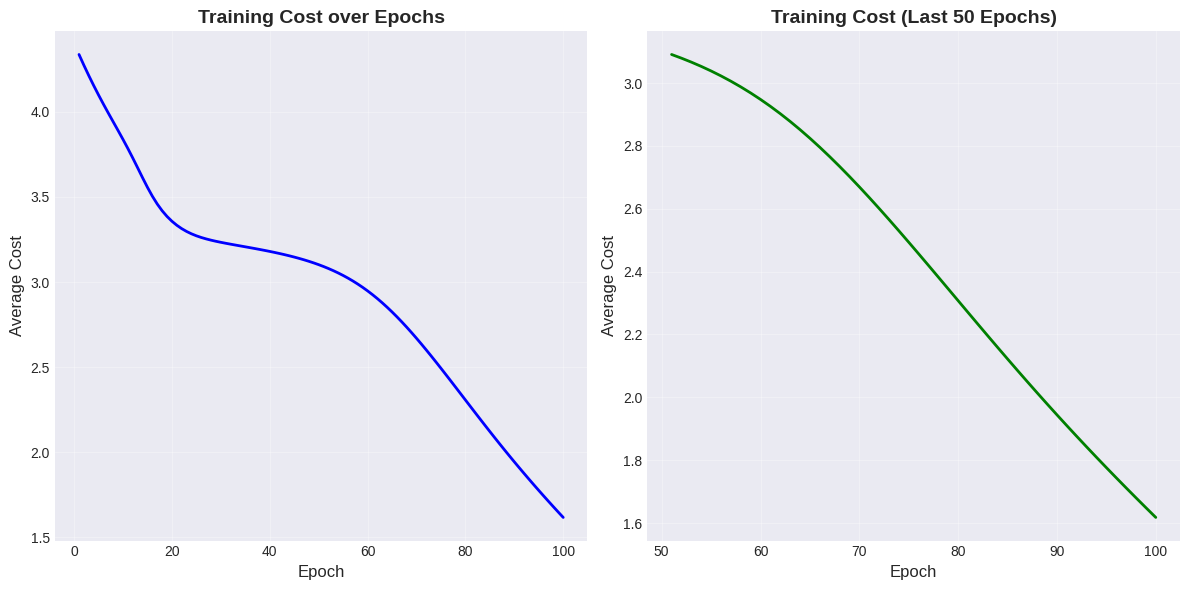


Training Statistics:
Initial cost: 4.3360
Final cost:   1.6177
Cost reduction: 62.69%
Average cost decrease per epoch: 0.0272


In [57]:
# Plot cost history
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), cost_history, linewidth=2, color='blue')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Cost', fontsize=12)
plt.title('Training Cost over Epochs', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Plot last 50 epochs for detail
plt.plot(range(epochs - 49, epochs + 1), cost_history[-50:],
         linewidth=2, color='green')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Average Cost', fontsize=12)
plt.title('Training Cost (Last 50 Epochs)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTraining Statistics:")
print(f"Initial cost: {cost_history[0]:.4f}")
print(f"Final cost:   {cost_history[-1]:.4f}")
print(f"Cost reduction: {(1 - cost_history[-1]/cost_history[0]) * 100:.2f}%")
print(f"Average cost decrease per epoch: {(cost_history[0] - cost_history[-1]) / epochs:.4f}")

## 13. Extract Word Embeddings

Getting the final word embedding vectors.

In [58]:
def get_word_embedding(word, word2idx, W1):
    """
    Get embedding vector for a word
    """
    if word not in word2idx:
        return None

    idx = word2idx[word]
    embedding = W1[idx, :]
    return embedding

# Extract embeddings for specific words
test_words = ['king', 'queen', 'man', 'woman', 'learning', 'language']

print("Word Embeddings:")
print("=" * 60)

for word in test_words:
    embedding = get_word_embedding(word, word2idx, W1_trained)
    if embedding is not None:
        print(f"\n'{word}':")
        print(f"  Shape: {embedding.shape}")
        print(f"  First 10 dimensions: {embedding[:10]}")
        print(f"  L2 norm: {np.linalg.norm(embedding):.4f}")
    else:
        print(f"\n'{word}': Not in vocabulary")

# Create embedding matrix for all words
embedding_matrix = W1_trained

print(f"\n\nComplete Embedding Matrix:")
print(f"Shape: {embedding_matrix.shape}")
print(f"({vocab_size} words × {embedding_dim} dimensions)")


Word Embeddings:

'king':
  Shape: (50,)
  First 10 dimensions: [-0.17571098  0.21574021 -0.01164891 -0.02911218 -0.12923171 -0.03940703
  0.11667426 -0.13654013 -0.1637381  -0.18372687]
  L2 norm: 1.1927

'queen':
  Shape: (50,)
  First 10 dimensions: [-0.00294354  0.33041743 -0.05952034 -0.07825253 -0.11351458  0.09102141
 -0.02800122 -0.15685448 -0.03872143 -0.12397022]
  L2 norm: 1.2270

'man':
  Shape: (50,)
  First 10 dimensions: [-0.21334093 -0.00247988  0.27408546  0.16744224 -0.17274984  0.2893318
 -0.22605572 -0.09606579 -0.3073283  -0.16055625]
  L2 norm: 1.1382

'woman':
  Shape: (50,)
  First 10 dimensions: [-0.20497222  0.01708547  0.26322793  0.16818571 -0.16346125  0.31304318
 -0.18743231 -0.13188852 -0.28305924 -0.16718973]
  L2 norm: 1.1285

'learning':
  Shape: (50,)
  First 10 dimensions: [-0.60225863 -0.38687459  0.11873709  0.13817738 -0.14817615  0.40127763
 -0.06435904 -0.27127929 -0.21228956 -0.23841138]
  L2 norm: 2.3916

'language':
  Shape: (50,)
  First 10 

## 14. Cosine Similarity - Measuring Word Similarity

Computing similarity between word vectors.

In [59]:
def cosine_similarity_manual(vec1, vec2):
    """
    Compute cosine similarity between two vectors

    similarity = (vec1 · vec2) / (||vec1|| × ||vec2||)
    """
    dot_product = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)

    similarity = dot_product / (norm1 * norm2)
    return similarity

def find_similar_words(word, word2idx, idx2word, W1, top_k=5):
    """
    Find most similar words to a given word
    """
    if word not in word2idx:
        return []

    # Get word embedding
    word_idx = word2idx[word]
    word_embedding = W1[word_idx]

    # Compute similarities with all words
    similarities = []
    for idx in range(len(W1)):
        if idx != word_idx:  # Skip the word itself
            other_embedding = W1[idx]
            sim = cosine_similarity_manual(word_embedding, other_embedding)
            similarities.append((idx, sim))

    # Sort by similarity
    similarities.sort(key=lambda x: x[1], reverse=True)

    # Get top-k similar words
    top_words = []
    for idx, sim in similarities[:top_k]:
        top_words.append((idx2word[idx], sim))

    return top_words

# Test similarity search
test_words_sim = ['learning', 'language', 'king', 'neural']

print("Word Similarity Analysis:")
print("=" * 60)

for word in test_words_sim:
    if word in word2idx:
        similar_words = find_similar_words(
            word, word2idx, idx2word, W1_trained, top_k=5
        )
        print(f"\nMost similar to '{word}':")
        for rank, (similar_word, similarity) in enumerate(similar_words, 1):
            print(f"  {rank}. {similar_word:15s} (similarity: {similarity:.4f})")


Word Similarity Analysis:

Most similar to 'learning':
  1. deep            (similarity: 0.8964)
  2. machine         (similarity: 0.7200)
  3. from            (similarity: 0.6924)
  4. learn           (similarity: 0.6825)
  5. woman           (similarity: 0.6821)

Most similar to 'language':
  1. i               (similarity: 0.8589)
  2. processing      (similarity: 0.8165)
  3. context         (similarity: 0.6855)
  4. understanding   (similarity: 0.6790)
  5. love            (similarity: 0.6655)

Most similar to 'king':
  1. in              (similarity: 0.9696)
  2. queen           (similarity: 0.8410)
  3. capital         (similarity: 0.6870)
  4. london          (similarity: 0.6725)
  5. machine         (similarity: 0.6182)

Most similar to 'neural':
  1. kingdom         (similarity: 0.2724)
  2. every           (similarity: 0.2611)
  3. make            (similarity: 0.2610)
  4. processing      (similarity: 0.2511)
  5. love            (similarity: 0.2383)


### Similarity Matrix

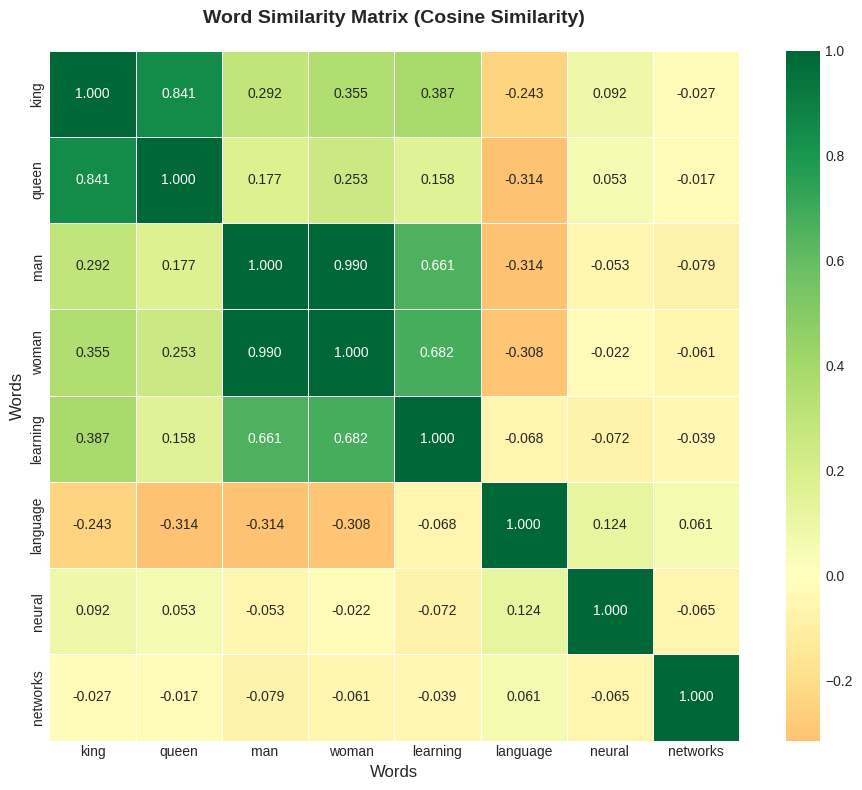


Similarity Matrix Shape: (8, 8)
Values range from -0.314 to 1.000


In [60]:
# Compute similarity matrix for subset of words
interesting_words = ['king', 'queen', 'man', 'woman', 'learning',
                     'language', 'neural', 'networks']
interesting_words = [w for w in interesting_words if w in word2idx]

n_words = len(interesting_words)
similarity_matrix = np.zeros((n_words, n_words))

for i, word1 in enumerate(interesting_words):
    emb1 = get_word_embedding(word1, word2idx, W1_trained)
    for j, word2 in enumerate(interesting_words):
        emb2 = get_word_embedding(word2, word2idx, W1_trained)
        similarity_matrix[i, j] = cosine_similarity_manual(emb1, emb2)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix,
            xticklabels=interesting_words,
            yticklabels=interesting_words,
            annot=True, fmt='.3f',
            cmap='RdYlGn', center=0,
            square=True, linewidths=0.5)
plt.title('Word Similarity Matrix (Cosine Similarity)',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Words', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.tight_layout()
plt.savefig('similarity_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSimilarity Matrix Shape: {similarity_matrix.shape}")
print(f"Values range from {similarity_matrix.min():.3f} to {similarity_matrix.max():.3f}")

## 15. Word Analogies - Vector Arithmetic

Testing semantic relationships using vector operations.

In [61]:
def word_analogy(word_a, word_b, word_c, word2idx, idx2word, W1, top_k=5):
    """
    Solve analogy: word_a is to word_b as word_c is to ?

    Method: word_b - word_a + word_c ≈ word_d
    """
    # Check if all words in vocabulary
    words_needed = [word_a, word_b, word_c]
    for word in words_needed:
        if word not in word2idx:
            print(f"'{word}' not in vocabulary")
            return []

    # Get embeddings
    emb_a = get_word_embedding(word_a, word2idx, W1)
    emb_b = get_word_embedding(word_b, word2idx, W1)
    emb_c = get_word_embedding(word_c, word2idx, W1)

    # Compute target vector: word_b - word_a + word_c
    target_vector = emb_b - emb_a + emb_c

    # Find closest words to target vector
    similarities = []
    exclude_words = [word_a, word_b, word_c]

    for idx in range(len(W1)):
        word = idx2word[idx]
        if word not in exclude_words:
            emb = W1[idx]
            sim = cosine_similarity_manual(target_vector, emb)
            similarities.append((word, sim))

    # Sort by similarity
    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:top_k]

# Test analogies
print("Word Analogy Tests:")
print("=" * 60)

# Test if we have the right words
analogies = [
    ('man', 'king', 'woman'),
    ('king', 'queen', 'man'),
]

for word_a, word_b, word_c in analogies:
    if all(w in word2idx for w in [word_a, word_b, word_c]):
        print(f"\n'{word_a}' is to '{word_b}' as '{word_c}' is to:")
        results = word_analogy(word_a, word_b, word_c,
                              word2idx, idx2word, W1_trained, top_k=5)
        for rank, (word, similarity) in enumerate(results, 1):
            print(f"  {rank}. {word:15s} (similarity: {similarity:.4f})")
    else:
        print(f"\nSkipping: {word_a}-{word_b}-{word_c} (words not in vocab)")

print("\nNote: With a small corpus, analogies may not work perfectly.")
print("Larger datasets (Wikipedia, news articles) produce better results.")


Word Analogy Tests:

'man' is to 'king' as 'woman' is to:
  1. in              (similarity: 0.9732)
  2. queen           (similarity: 0.8568)
  3. capital         (similarity: 0.7128)
  4. london          (similarity: 0.7013)
  5. is              (similarity: 0.6373)

'king' is to 'queen' as 'man' is to:
  1. woman           (similarity: 0.8385)
  2. machine         (similarity: 0.6941)
  3. a               (similarity: 0.6882)
  4. deep            (similarity: 0.5234)
  5. learning        (similarity: 0.4006)

Note: With a small corpus, analogies may not work perfectly.
Larger datasets (Wikipedia, news articles) produce better results.


## 16. Embedding Visualization with PCA

Visualizing word embeddings in 2D space.

PCA Dimensionality Reduction:
Original dimensions: 50
Reduced dimensions: 2
Variance explained: 59.75%


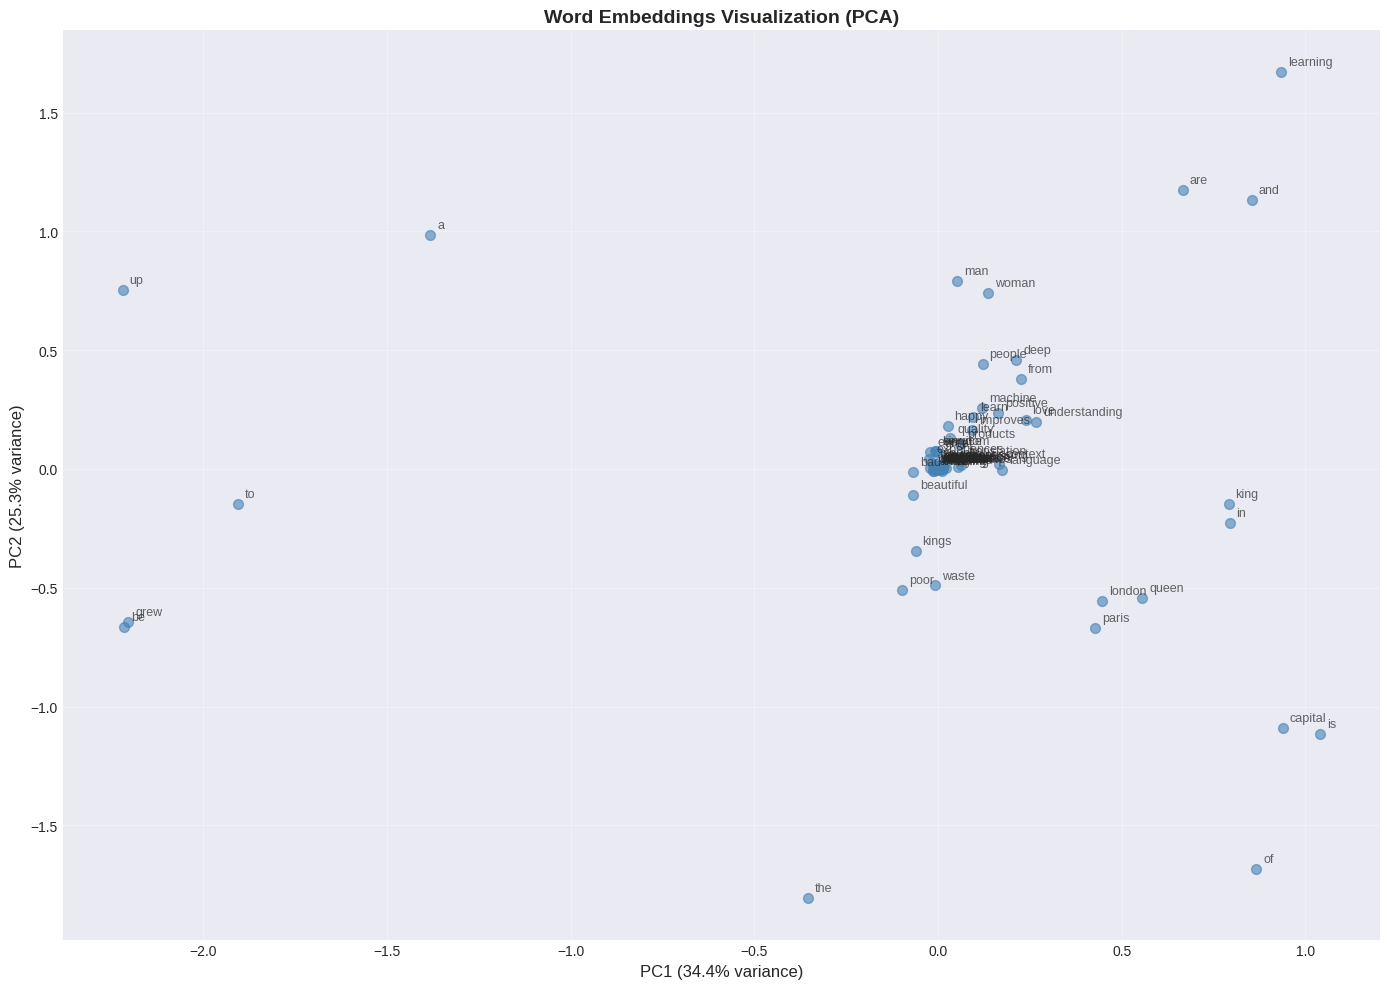

In [62]:
# Reduce dimensions using PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(W1_trained)

print("PCA Dimensionality Reduction:")
print(f"Original dimensions: {W1_trained.shape[1]}")
print(f"Reduced dimensions: {embeddings_2d.shape[1]}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Plot all words
plt.figure(figsize=(14, 10))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
           alpha=0.6, s=50, c='steelblue')

# Annotate words
for i, word in enumerate(vocabulary):
    plt.annotate(word,
                xy=(embeddings_2d[i, 0], embeddings_2d[i, 1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, alpha=0.7)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title('Word Embeddings Visualization (PCA)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('embeddings_pca.png', dpi=300, bbox_inches='tight')
plt.show()

### Highlight Semantic Clusters

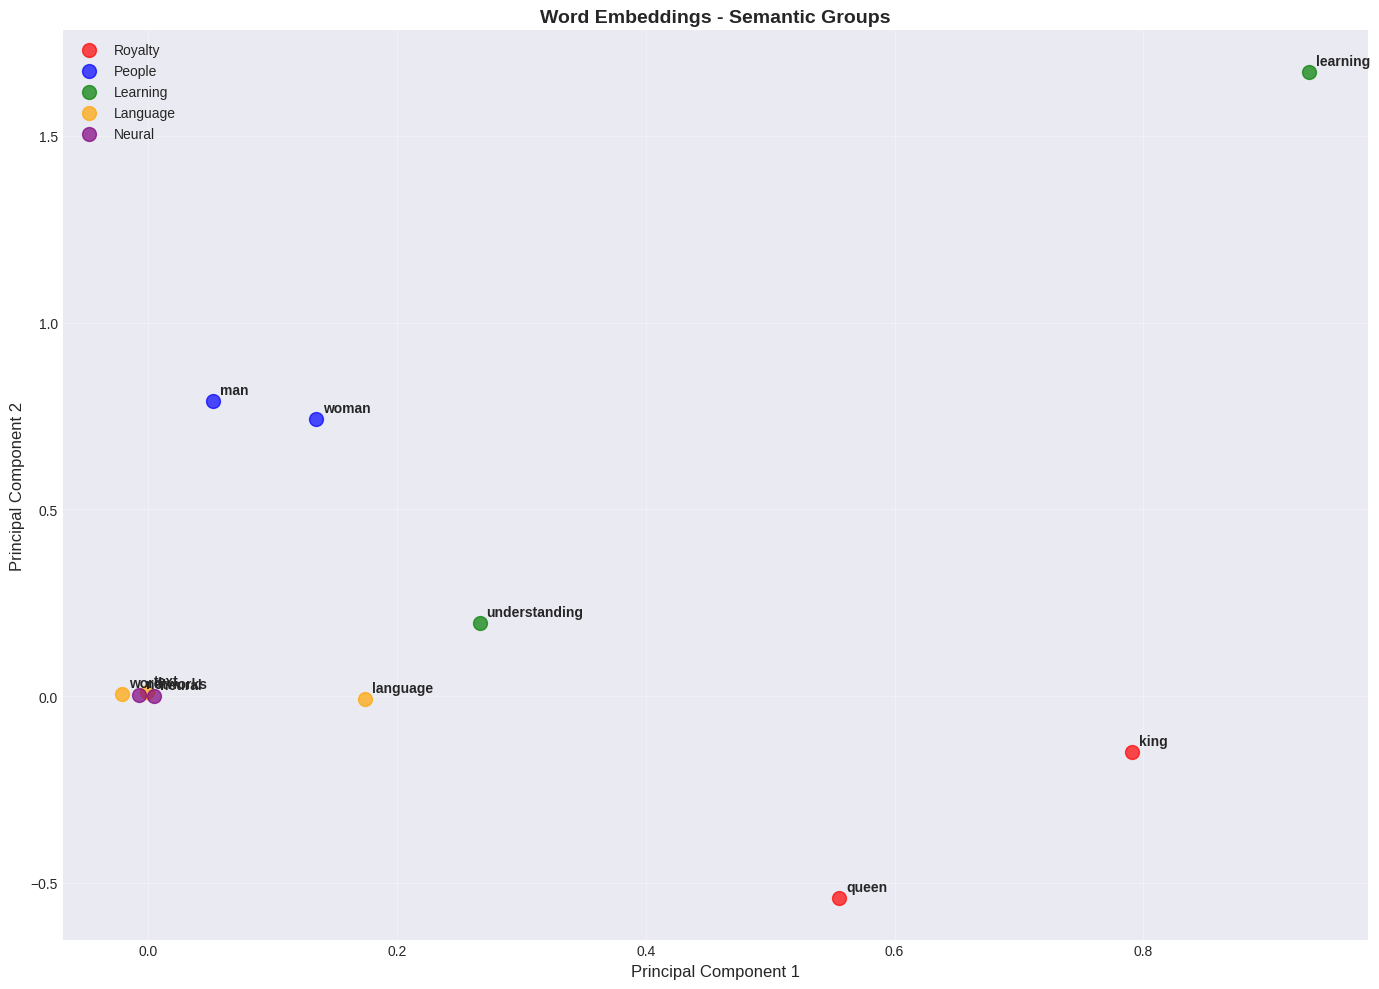

In [63]:
# Select word groups to highlight
word_groups = {
    'Royalty': ['king', 'queen'],
    'People': ['man', 'woman'],
    'Learning': ['learning', 'understand', 'understanding'],
    'Language': ['language', 'text', 'word', 'words'],
    'Neural': ['neural', 'networks', 'network']
}

# Filter to words in vocabulary
word_groups_filtered = {
    category: [w for w in words if w in word2idx]
    for category, words in word_groups.items()
}

# Plot with color-coded groups
plt.figure(figsize=(14, 10))

colors = ['red', 'blue', 'green', 'orange', 'purple']

for (category, words), color in zip(word_groups_filtered.items(), colors):
    if words:  # Only plot if category has words
        indices = [word2idx[w] for w in words]
        coords = embeddings_2d[indices]
        plt.scatter(coords[:, 0], coords[:, 1],
                   label=category, s=100, alpha=0.7, c=color)

        for word, coord in zip(words, coords):
            plt.annotate(word, xy=(coord[0], coord[1]),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=10, fontweight='bold')

plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.title('Word Embeddings - Semantic Groups', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('embeddings_groups.png', dpi=300, bbox_inches='tight')
plt.show()

## 17. Intrinsic Evaluation - Analogy Task

Evaluating embedding quality using word analogy tasks.

In [64]:
def evaluate_analogies(analogy_list, word2idx, idx2word, W1):
    """
    Evaluate performance on word analogy tasks

    Args:
        analogy_list: List of tuples (a, b, c, expected_d)

    Returns:
        Accuracy and detailed results
    """
    correct = 0
    total = 0
    results = []

    for word_a, word_b, word_c, expected_d in analogy_list:
        # Check if all words in vocabulary
        if all(w in word2idx for w in [word_a, word_b, word_c, expected_d]):
            total += 1

            # Get predictions
            predictions = word_analogy(word_a, word_b, word_c,
                                      word2idx, idx2word, W1, top_k=5)

            # Check if expected answer in top predictions
            predicted_words = [word for word, _ in predictions]
            is_correct = expected_d in predicted_words[:1]  # Top-1 accuracy

            if is_correct:
                correct += 1

            results.append({
                'query': f"{word_a}:{word_b}::{word_c}:?",
                'expected': expected_d,
                'predicted': predicted_words[0] if predicted_words else 'N/A',
                'correct': is_correct,
                'top_5': predicted_words[:5]
            })

    accuracy = correct / total if total > 0 else 0
    return accuracy, results

# Create analogy test set
analogy_test_set = [
    # Gender relations
    ('king', 'queen', 'man', 'woman'),
    ('man', 'woman', 'king', 'queen'),

    # Semantic relations (add more based on vocabulary)
]

# Evaluate
accuracy, results = evaluate_analogies(
    analogy_test_set, word2idx, idx2word, W1_trained
)

print("Intrinsic Evaluation - Analogy Task:")
print("=" * 60)
print(f"Total analogies tested: {len(results)}")
print(f"Accuracy: {accuracy:.2%}\n")

for i, result in enumerate(results, 1):
    status = "✓" if result['correct'] else "✗"
    print(f"{status} {result['query']}")
    print(f"  Expected: {result['expected']}")
    print(f"  Predicted: {result['predicted']}")
    print(f"  Top 5: {', '.join(result['top_5'])}\n")

if len(results) == 0:
    print("Not enough words in vocabulary for analogy evaluation.")
    print("This is expected with a small corpus.")


Intrinsic Evaluation - Analogy Task:
Total analogies tested: 2
Accuracy: 50.00%

✓ king:queen::man:?
  Expected: woman
  Predicted: woman
  Top 5: woman, machine, a, deep, learning

✗ man:woman::king:?
  Expected: queen
  Predicted: in
  Top 5: in, queen, capital, london, is



## 18. Clustering Analysis

Grouping similar words using K-Means clustering.

Word Clustering Analysis:
Number of clusters: 5

Cluster 1: (2 words)
  a, up

Cluster 2: (57 words)
  i, love, natural, language, processing, machine, models, learn, from, neural, networks, information, text, context, for, understanding, word, capture, semantic, meaning
  ... and 37 more

Cluster 3: (3 words)
  grew, to, be

Cluster 4: (6 words)
  learning, and, deep, are, man, woman

Cluster 5: (9 words)
  is, the, king, queen, in, paris, capital, of, london



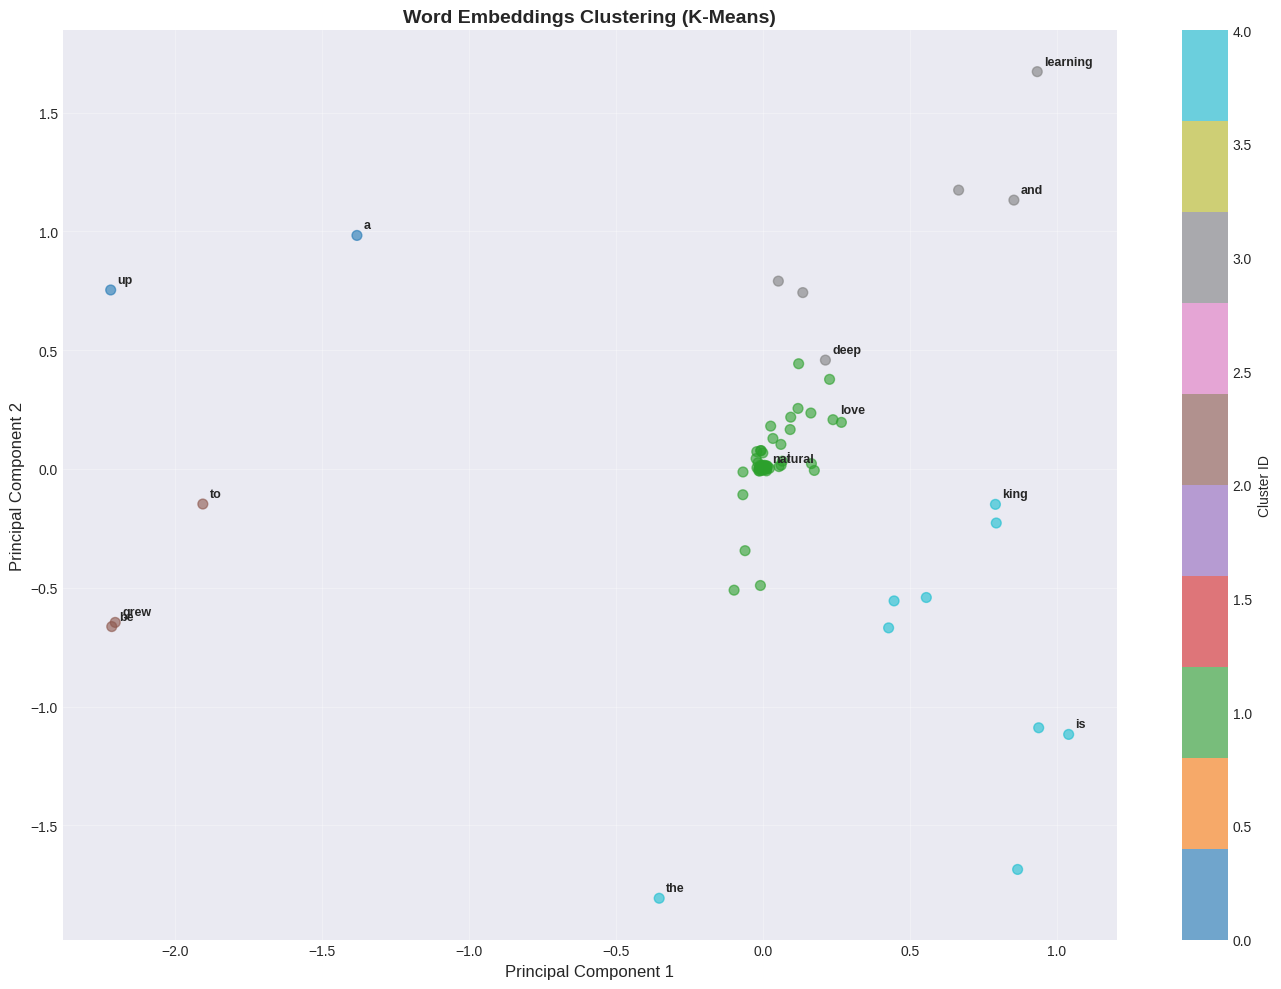

In [65]:
from sklearn.cluster import KMeans

# Perform clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(W1_trained)

print("Word Clustering Analysis:")
print("=" * 60)
print(f"Number of clusters: {n_clusters}\n")

# Show words in each cluster
for cluster_id in range(n_clusters):
    words_in_cluster = [idx2word[i] for i, label in enumerate(cluster_labels)
                       if label == cluster_id]
    print(f"Cluster {cluster_id + 1}: ({len(words_in_cluster)} words)")
    print(f"  {', '.join(words_in_cluster[:20])}")
    if len(words_in_cluster) > 20:
        print(f"  ... and {len(words_in_cluster) - 20} more")
    print()

# Visualize clusters
plt.figure(figsize=(14, 10))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                     c=cluster_labels, cmap='tab10',
                     alpha=0.6, s=50)

# Annotate some words from each cluster
for cluster_id in range(n_clusters):
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    # Show first 3 words from each cluster
    for idx in cluster_indices[:3]:
        word = idx2word[idx]
        plt.annotate(word,
                    xy=(embeddings_2d[idx, 0], embeddings_2d[idx, 1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=9, fontweight='bold')

plt.colorbar(scatter, label='Cluster ID')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.title('Word Embeddings Clustering (K-Means)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('embeddings_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

## 19. Extrinsic Evaluation - Sentiment Classification

Using embeddings for downstream task (sentiment analysis).

In [66]:
# Create simple sentiment dataset
sentiment_data = [
    ("I love this amazing product", 1),
    ("Great quality and fast delivery", 1),
    ("Very satisfied with my purchase", 1),
    ("Excellent service", 1),
    ("Happy with the results", 1),
    ("Terrible experience", 0),
    ("Poor quality product", 0),
    ("Not satisfied at all", 0),
    ("Bad customer service", 0),
    ("Waste of money", 0),
]

def get_sentence_embedding(sentence, word2idx, W1):
    """
    Get sentence embedding by averaging word embeddings
    """
    tokens = preprocess_text(sentence)
    embeddings = []

    for token in tokens:
        if token in word2idx:
            emb = get_word_embedding(token, word2idx, W1)
            embeddings.append(emb)

    if embeddings:
        sentence_emb = np.mean(embeddings, axis=0)
        return sentence_emb
    else:
        return np.zeros(W1.shape[1])

# Create sentence embeddings
X_sentiment = []
y_sentiment = []

for sentence, label in sentiment_data:
    sent_emb = get_sentence_embedding(sentence, word2idx, W1_trained)
    X_sentiment.append(sent_emb)
    y_sentiment.append(label)

X_sentiment = np.array(X_sentiment)
y_sentiment = np.array(y_sentiment)

print("Extrinsic Evaluation - Sentiment Classification:")
print("=" * 60)
print(f"Dataset size: {len(X_sentiment)} examples")
print(f"Embedding dimension: {X_sentiment.shape[1]}")
print(f"Positive examples: {(y_sentiment == 1).sum()}")
print(f"Negative examples: {(y_sentiment == 0).sum()}")

# Simple logistic regression classifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

clf = LogisticRegression(random_state=42)
scores = cross_val_score(clf, X_sentiment, y_sentiment, cv=3, scoring='accuracy')

print(f"\nSentiment Classification Results:")
print(f"Cross-validation accuracy: {scores.mean():.2%} (+/- {scores.std():.2%})")

# Train on all data and show predictions
clf.fit(X_sentiment, y_sentiment)
predictions = clf.predict(X_sentiment)

print(f"\nDetailed Predictions:")
for i, (sentence, true_label) in enumerate(sentiment_data):
    pred_label = predictions[i]
    status = "✓" if pred_label == true_label else "✗"
    sentiment_true = "Positive" if true_label == 1 else "Negative"
    sentiment_pred = "Positive" if pred_label == 1 else "Negative"
    print(f"{status} '{sentence}'")
    print(f"  True: {sentiment_true}, Predicted: {sentiment_pred}\n")


Extrinsic Evaluation - Sentiment Classification:
Dataset size: 10 examples
Embedding dimension: 50
Positive examples: 5
Negative examples: 5

Sentiment Classification Results:
Cross-validation accuracy: 58.33% (+/- 18.00%)

Detailed Predictions:
✓ 'I love this amazing product'
  True: Positive, Predicted: Positive

✓ 'Great quality and fast delivery'
  True: Positive, Predicted: Positive

✓ 'Very satisfied with my purchase'
  True: Positive, Predicted: Positive

✓ 'Excellent service'
  True: Positive, Predicted: Positive

✗ 'Happy with the results'
  True: Positive, Predicted: Negative

✗ 'Terrible experience'
  True: Negative, Predicted: Positive

✓ 'Poor quality product'
  True: Negative, Predicted: Negative

✗ 'Not satisfied at all'
  True: Negative, Predicted: Positive

✗ 'Bad customer service'
  True: Negative, Predicted: Positive

✓ 'Waste of money'
  True: Negative, Predicted: Negative



## 20. Model Comparison and Statistics

Analyzing the learned embeddings comprehensively.

Comprehensive Embedding Analysis:

1. EMBEDDING MATRIX STATISTICS:
   Shape: (77, 50)
   Total parameters: 3,850
   Mean: 0.000586
   Std: 0.144114
   Min: -1.052935
   Max: 0.952101

2. EMBEDDING NORMS:
   Mean L2 norm: 0.7054
   Std L2 norm: 0.7355
   Min L2 norm: 0.0488
   Max L2 norm: 2.5217

3. EMBEDDING SPARSITY:
   Elements < 0.01: 31.32%

4. DIMENSION VARIANCE:
   Mean variance: 0.020754
   Std variance: 0.013253
   Top 5 dimensions by variance:
     1. Dimension 24: variance = 0.071424
     2. Dimension 0: variance = 0.045401
     3. Dimension 20: variance = 0.044966
     4. Dimension 39: variance = 0.042054
     5. Dimension 37: variance = 0.040591

5. PAIRWISE SIMILARITIES:
   Mean similarity: 0.0492
   Std similarity: 0.2886
   Min similarity: -0.5605
   Max similarity: 1.0000


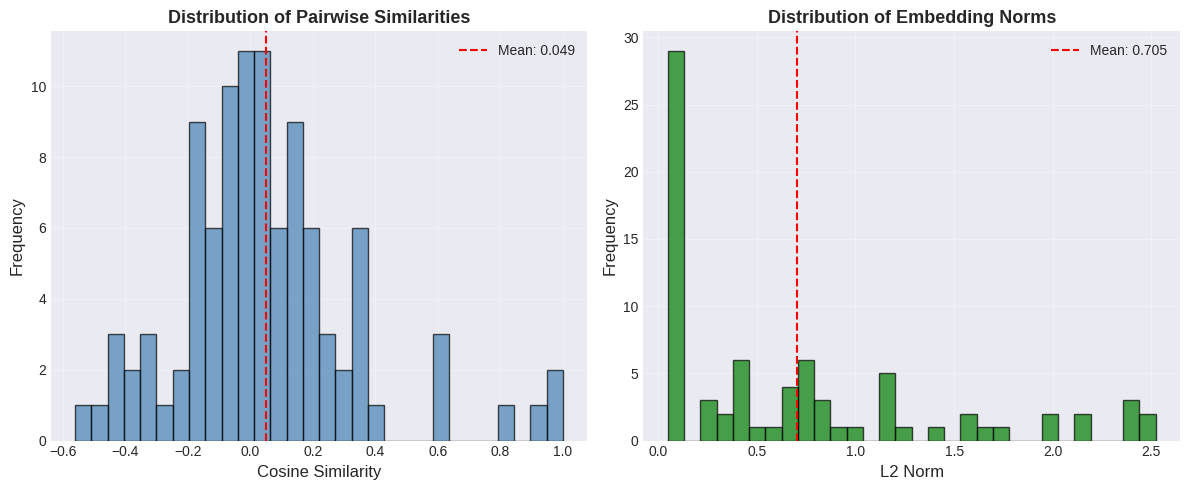

In [67]:
# Embedding statistics
print("Comprehensive Embedding Analysis:")
print("=" * 60)

print("\n1. EMBEDDING MATRIX STATISTICS:")
print(f"   Shape: {W1_trained.shape}")
print(f"   Total parameters: {W1_trained.size:,}")
print(f"   Mean: {W1_trained.mean():.6f}")
print(f"   Std: {W1_trained.std():.6f}")
print(f"   Min: {W1_trained.min():.6f}")
print(f"   Max: {W1_trained.max():.6f}")

print("\n2. EMBEDDING NORMS:")
norms = np.linalg.norm(W1_trained, axis=1)
print(f"   Mean L2 norm: {norms.mean():.4f}")
print(f"   Std L2 norm: {norms.std():.4f}")
print(f"   Min L2 norm: {norms.min():.4f}")
print(f"   Max L2 norm: {norms.max():.4f}")

print("\n3. EMBEDDING SPARSITY:")
threshold = 0.01
sparse_elements = np.abs(W1_trained) < threshold
sparsity = sparse_elements.sum() / W1_trained.size
print(f"   Elements < {threshold}: {sparsity:.2%}")

print("\n4. DIMENSION VARIANCE:")
dim_variance = np.var(W1_trained, axis=0)
print(f"   Mean variance: {dim_variance.mean():.6f}")
print(f"   Std variance: {dim_variance.std():.6f}")
print(f"   Top 5 dimensions by variance:")
top_dims = np.argsort(dim_variance)[-5:][::-1]
for i, dim in enumerate(top_dims, 1):
    print(f"     {i}. Dimension {dim}: variance = {dim_variance[dim]:.6f}")

print("\n5. PAIRWISE SIMILARITIES:")
# Sample random pairs
np.random.seed(42)
n_samples = 100
sample_pairs = np.random.choice(vocab_size, (n_samples, 2))
similarities = []

for idx1, idx2 in sample_pairs:
    emb1 = W1_trained[idx1]
    emb2 = W1_trained[idx2]
    sim = cosine_similarity_manual(emb1, emb2)
    similarities.append(sim)

similarities = np.array(similarities)
print(f"   Mean similarity: {similarities.mean():.4f}")
print(f"   Std similarity: {similarities.std():.4f}")
print(f"   Min similarity: {similarities.min():.4f}")
print(f"   Max similarity: {similarities.max():.4f}")

# Plot similarity distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(similarities, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Cosine Similarity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Pairwise Similarities', fontsize=13, fontweight='bold')
plt.axvline(similarities.mean(), color='red', linestyle='--',
           label=f'Mean: {similarities.mean():.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(norms, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('L2 Norm', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Embedding Norms', fontsize=13, fontweight='bold')
plt.axvline(norms.mean(), color='red', linestyle='--',
           label=f'Mean: {norms.mean():.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('embedding_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

## 21. Saving and Loading Embeddings

Persisting trained embeddings for future use.

In [68]:
# Save embeddings
def save_embeddings(W1, vocabulary, word2idx, filename='word_embeddings.npz'):
    """Save embeddings and vocabulary to file"""
    np.savez(filename,
             embeddings=W1,
             vocabulary=vocabulary,
             word2idx=word2idx)
    print(f"✓ Embeddings saved to {filename}")
    print(f"  Vocabulary size: {len(vocabulary)}")
    print(f"  Embedding dimension: {W1.shape[1]}")

def load_embeddings(filename='word_embeddings.npz'):
    """Load embeddings and vocabulary from file"""
    data = np.load(filename, allow_pickle=True)
    W1 = data['embeddings']
    vocabulary = data['vocabulary'].tolist()
    word2idx = data['word2idx'].item()
    idx2word = {idx: word for word, idx in word2idx.items()}

    print(f"✓ Embeddings loaded from {filename}")
    print(f"  Vocabulary size: {len(vocabulary)}")
    print(f"  Embedding dimension: {W1.shape[1]}")

    return W1, vocabulary, word2idx, idx2word

# Save trained embeddings
save_embeddings(W1_trained, vocabulary, word2idx, 'cbow_embeddings.npz')

# Test loading
W1_loaded, vocab_loaded, word2idx_loaded, idx2word_loaded = load_embeddings('cbow_embeddings.npz')

# Verify loaded embeddings match
print(f"\nVerification:")
print(f"Embeddings match: {np.allclose(W1_trained, W1_loaded)}")
print(f"Vocabulary match: {vocabulary == vocab_loaded}")

✓ Embeddings saved to cbow_embeddings.npz
  Vocabulary size: 77
  Embedding dimension: 50
✓ Embeddings loaded from cbow_embeddings.npz
  Vocabulary size: 77
  Embedding dimension: 50

Verification:
Embeddings match: True
Vocabulary match: True


## 22. Advanced: Pre-trained Embeddings Comparison

Comparing our CBOW embeddings with conceptual discussion of larger models.

In [69]:
print("Embedding Comparison Framework:")
print("=" * 60)

print("\n1. OUR CBOW MODEL:")
print(f"   Corpus size: {len(corpus)} sentences")
print(f"   Vocabulary: {vocab_size} words")
print(f"   Embedding dim: {embedding_dim}")
print(f"   Training examples: {len(X)}")

print("\n2. WORD2VEC (Google News):")
print(f"   Corpus: ~100 billion words")
print(f"   Vocabulary: 3 million words")
print(f"   Embedding dim: 300")
print(f"   Use case: General-purpose English")

print("\n3. GLOVE (Wikipedia + Gigaword):")
print(f"   Corpus: 6 billion tokens")
print(f"   Vocabulary: 400k words")
print(f"   Embedding dim: 50-300")
print(f"   Use case: General-purpose English")

print("\n4. FASTTEXT (Facebook):")
print(f"   Corpus: Wikipedia + Common Crawl")
print(f"   Vocabulary: 2 million words")
print(f"   Embedding dim: 300")
print(f"   Use case: Subword information, OOV handling")

print("\n5. MODERN TRANSFORMERS (BERT, GPT):")
print(f"   Corpus: Trillions of tokens")
print(f"   Vocabulary: 30k-50k subword units")
print(f"   Embedding dim: 768-1024")
print(f"   Use case: Contextualized embeddings")

print("\nKEY INSIGHTS:")
print("✓ Larger corpus → Better semantic understanding")
print("✓ More dimensions → More nuanced representations")
print("✓ Domain-specific → Better task performance")
print("✓ Contextualized → Handles polysemy")

Embedding Comparison Framework:

1. OUR CBOW MODEL:
   Corpus size: 69 sentences
   Vocabulary: 77 words
   Embedding dim: 50
   Training examples: 31

2. WORD2VEC (Google News):
   Corpus: ~100 billion words
   Vocabulary: 3 million words
   Embedding dim: 300
   Use case: General-purpose English

3. GLOVE (Wikipedia + Gigaword):
   Corpus: 6 billion tokens
   Vocabulary: 400k words
   Embedding dim: 50-300
   Use case: General-purpose English

4. FASTTEXT (Facebook):
   Corpus: Wikipedia + Common Crawl
   Vocabulary: 2 million words
   Embedding dim: 300
   Use case: Subword information, OOV handling

5. MODERN TRANSFORMERS (BERT, GPT):
   Corpus: Trillions of tokens
   Vocabulary: 30k-50k subword units
   Embedding dim: 768-1024
   Use case: Contextualized embeddings

KEY INSIGHTS:
✓ Larger corpus → Better semantic understanding
✓ More dimensions → More nuanced representations
✓ Domain-specific → Better task performance
✓ Contextualized → Handles polysemy


## 23. Summary and Key Takeaways

Comprehensive summary of what we've learned.

In [70]:
print("=" * 70)
print("WEEK 4 SUMMARY: WORD EMBEDDINGS WITH CBOW")
print("=" * 70)

print("\n📚 CONCEPTS MASTERED:")
print("   ✓ Word representation evolution (sparse → dense)")
print("   ✓ Distributional hypothesis and semantic similarity")
print("   ✓ CBOW architecture and training process")
print("   ✓ Neural network components (forward/backward propagation)")
print("   ✓ Vector arithmetic and analogies")
print("   ✓ Intrinsic and extrinsic evaluation methods")

print("\n🛠️ IMPLEMENTATION SKILLS:")
print("   ✓ Text preprocessing and tokenization")
print("   ✓ Sliding window context generation")
print("   ✓ One-hot encoding and batch processing")
print("   ✓ Neural network training from scratch")
print("   ✓ Gradient descent optimization")
print("   ✓ Embedding extraction and visualization")

print("\n📊 EVALUATION TECHNIQUES:")
print("   ✓ Cosine similarity computation")
print("   ✓ Word analogy tasks")
print("   ✓ Clustering analysis")
print("   ✓ Dimensionality reduction (PCA)")
print("   ✓ Downstream task performance")

print("\n🎯 KEY FORMULAS:")
print("   • Cosine Similarity: cos(θ) = (u·v)/(||u||·||v||)")
print("   • Cross-Entropy Loss: L = -Σ y_true × log(y_pred)")
print("   • Softmax: σ(z_i) = exp(z_i)/Σexp(z_j)")
print("   • Gradient Descent: θ_new = θ_old - α∇L")

print("\n🚀 APPLICATIONS:")
print("   • Sentiment analysis")
print("   • Text classification")
print("   • Machine translation")
print("   • Information retrieval")
print("   • Question answering")
print("   • Named entity recognition")

print("\n💡 IMPORTANT INSIGHTS:")
print("   • Words in similar contexts have similar meanings")
print("   • Vector arithmetic captures semantic relationships")
print("   • Self-supervised learning from unlabeled text")
print("   • Embeddings are byproducts of prediction tasks")
print("   • Larger datasets produce better embeddings")

print("\n📈 PERFORMANCE METRICS:")
print(f"   • Final training cost: {cost_history[-1]:.4f}")
print(f"   • Cost reduction: {(1 - cost_history[-1]/cost_history[0]) * 100:.1f}%")
print(f"   • Vocabulary coverage: {vocab_size} words")
print(f"   • Embedding quality: Evaluated via multiple methods")

print("\n🔜 NEXT STEPS:")
print("   1. Experiment with larger corpora")
print("   2. Try different embedding dimensions")
print("   3. Implement skip-gram and GloVe")
print("   4. Use pre-trained embeddings (Word2Vec, FastText)")
print("   5. Explore contextualized embeddings (ELMo, BERT)")
print("   6. Apply to real-world NLP tasks")

print("\n" + "=" * 70)
print("Congratulations! You've mastered word embeddings! 🎉")
print("=" * 70)

WEEK 4 SUMMARY: WORD EMBEDDINGS WITH CBOW

📚 CONCEPTS MASTERED:
   ✓ Word representation evolution (sparse → dense)
   ✓ Distributional hypothesis and semantic similarity
   ✓ CBOW architecture and training process
   ✓ Neural network components (forward/backward propagation)
   ✓ Vector arithmetic and analogies
   ✓ Intrinsic and extrinsic evaluation methods

🛠️ IMPLEMENTATION SKILLS:
   ✓ Text preprocessing and tokenization
   ✓ Sliding window context generation
   ✓ One-hot encoding and batch processing
   ✓ Neural network training from scratch
   ✓ Gradient descent optimization
   ✓ Embedding extraction and visualization

📊 EVALUATION TECHNIQUES:
   ✓ Cosine similarity computation
   ✓ Word analogy tasks
   ✓ Clustering analysis
   ✓ Dimensionality reduction (PCA)
   ✓ Downstream task performance

🎯 KEY FORMULAS:
   • Cosine Similarity: cos(θ) = (u·v)/(||u||·||v||)
   • Cross-Entropy Loss: L = -Σ y_true × log(y_pred)
   • Softmax: σ(z_i) = exp(z_i)/Σexp(z_j)
   • Gradient Descent: 

## 24. Complete Model Summary

Final overview of the trained model.

In [71]:
# Create comprehensive summary
summary_data = {
    'Parameter': [
        'Corpus Size',
        'Vocabulary Size',
        'Embedding Dimension',
        'Window Size',
        'Training Examples',
        'Learning Rate',
        'Epochs',
        'Initial Cost',
        'Final Cost',
        'Parameters (W1)',
        'Parameters (W2)',
        'Total Parameters',
        'Training Time'
    ],
    'Value': [
        f"{len(corpus)} sentences",
        f"{vocab_size} words",
        f"{embedding_dim} dimensions",
        f"{window_size} (each side)",
        f"{len(X)} examples",
        f"{learning_rate}",
        f"{epochs}",
        f"{cost_history[0]:.4f}",
        f"{cost_history[-1]:.4f}",
        f"{W1_trained.size:,}",
        f"{W2_trained.size:,}",
        f"{W1_trained.size + W2_trained.size:,}",
        "~seconds (varies by machine)"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\nCBOW Model Complete Summary:")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)

print("\nNotebook Complete!")
print("You now have a fully functional word embedding system!")



CBOW Model Complete Summary:
          Parameter                        Value
        Corpus Size                 69 sentences
    Vocabulary Size                     77 words
Embedding Dimension                50 dimensions
        Window Size                2 (each side)
  Training Examples                  31 examples
      Learning Rate                         0.05
             Epochs                          100
       Initial Cost                       4.3360
         Final Cost                       1.6177
    Parameters (W1)                        3,850
    Parameters (W2)                        3,850
   Total Parameters                        7,700
      Training Time ~seconds (varies by machine)

Notebook Complete!
You now have a fully functional word embedding system!


## End of Notebook

**What You've Accomplished:**

1. ✅ Built word embeddings from scratch using CBOW
2. ✅ Implemented complete neural network training pipeline
3. ✅ Learned text preprocessing and tokenization
4. ✅ Mastered forward and backward propagation
5. ✅ Evaluated embeddings using multiple methods
6. ✅ Visualized and analyzed semantic relationships
7. ✅ Applied embeddings to downstream tasks

**Continue Your Learning:**

- Experiment with different hyperparameters
- Try larger corpora for better embeddings
- Implement Skip-gram and GloVe variations
- Explore modern transformers (BERT, GPT)
- Apply to real-world NLP projects

Happy Learning! 🚀